In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import urllib.request
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(url, 'input.txt')

('input.txt', <http.client.HTTPMessage at 0x7c45012db710>)

In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')

True
Tesla T4


In [4]:
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

with open('input.txt', 'r', encoding='utf-8') as file:
    file_content = file.read()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# hyperparameters
batch_size = 64
block_size = 256

d_model = 384
num_heads = 6
n_layers = 6
d_ff = 4 * d_model

lr = 3e-4
max_iters = 2500
eval_interval = 500

class Head(nn.Module):
    def __init__(self, d_model, d_k, d_v):
        super().__init__()
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_v, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        Q = self.W_Q(x) # Query vector - x is the embedding vector
        K = self.W_K(x) # Key vector - sequence of vectors that can potentially answer the queries
        V = self.W_V(x) # Value vector(from down-projection) - used to update the embeddings(EX: you want the embedding of one word that's related to another to cause a change to
                        # that other word that more specifically encodes the now better known description now that you have that new context)
        d_k = Q.shape[-1]
        scores = Q @ K.transpose(-2, -1) / (d_k**0.5) # computes a dot product to see how well each key matches each query(larger dot product = more aligned)
        
        # mask the scores()
        T = scores.shape[-1]
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        weights = F.softmax(scores, dim=-1)

        out = weights @ V # think of V as changing the vector of the previous embedding now that we have more context on that embedding
                          # for each column in the grid, you mulyiply each of the value vectors by the corresponding weight in that column(from the softmax)
                          # then we add together all of these rescaled values(the weight*value vector) in the column(i.e. each token) to update the embedding
                          # WARNING: the process described above is transposed so it's actually across rows rather than along columns
                          # EX: 'fluffy' and 'blue' adding more context to the next word 'creature' bc they have large proportions of the value vectors, while the other words get
                          # zeroed out
        return out # result vector

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        d_k = d_model // num_heads

        self.heads = nn.ModuleList([Head(d_model, d_k, d_k) for _ in range(num_heads)])
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        head_outs = [h(x) for h in self.heads] # heads_out[h] is a single head's result vector [B, T, 64]

        out = torch.cat(head_outs, dim=-1) # we concatenate rather than add since all of these head's dimensions mean different things to each head, even tho they're all 64
        out = self.proj(out) # learned mixing layer that lets the heads' result vectors interact and get recombined before rejoining the residual stream
                             # does the up-projection and the weight matrix contains all 6 value-up matrices then does the summing 
                             # W_O^H * [r^h1, r^h2, ...]
        return out

class Block(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward_network = nn.Sequential( # MLP layer
            nn.Linear(d_model, d_ff), # expand: d_model -> d_ff(4 * d_model)
            nn.ReLU(),
            nn.Linear(d_ff, d_model), # project back: d_ff -> d_model
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        # Pre-norm(make sure to explain why I chose this instead of Post-norm) + residual connections
        x = x + self.attention(self.ln1(x)) 
        x = x + self.feed_forward_network(self.ln2(x))     
        
        return x
    
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, block_size, num_heads, n_layers, d_ff):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(block_size, d_model)
        self.blocks = nn.Sequential(*[Block(d_model, num_heads, d_ff) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None

        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)

            next_idx = torch.multinomial(probs, num_samples=1) # chose sampling over argmax
            idx = torch.cat((idx, next_idx), dim=1)

        self.train()

        return idx

sorted_chars = sorted(set(file_content))
vocab_size = len(sorted_chars)

ints = list(range(vocab_size))

stoi = dict(zip(sorted_chars, ints)) # maps character : integer
itos = dict(zip(ints, sorted_chars)) # maps integer : character

encoder = lambda s: [stoi[c] for c in s]
decoder = lambda l: ''.join(itos[i] for i in l)

data = torch.tensor(encoder(file_content), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split, batch_size, block_size):
    data = train_data if split == 'train' else val_data

    ii = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([data[i : i + block_size] for i in ii])
    y = torch.stack([data[i+1 : i + block_size + 1] for i in ii])
    x, y = x.to(device), y.to(device)

    return x, y

@torch.no_grad()
def estimate_loss(model, eval_iters=200):
    model.eval()
    out = {}

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            xb, yb = get_batch(split, batch_size, block_size)
            logits, loss = model(xb, yb)
            losses[k] = loss.item()
        
        out[split] = losses.mean()
    
    model.train()

    return out

model = GPT(vocab_size, d_model, block_size, num_heads, n_layers, d_ff)
model = model.to(device)

optimizer = torch.optim.AdamW(lr=lr, params=model.parameters())

In [6]:
for iter in range(max_iters):

    if iter % eval_interval == 0:
        losses = estimate_loss(model)
        print(f'iterations: {iter}, train loss: {losses['train']:.4f}, val loss: {losses['val']:.4f}')
    
    xb, yb = get_batch('train', batch_size, block_size)
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

context = torch.zeros((1, 1), dtype=torch.long, device=device)
out = model.generate(context, max_new_tokens=500)

print(decoder(out[0].tolist()))

iterations: 0, train loss: 4.2849, val loss: 4.2824
iterations: 500, train loss: 1.8223, val loss: 1.9461
iterations: 1000, train loss: 1.4772, val loss: 1.6810
iterations: 1500, train loss: 1.3249, val loss: 1.5778
iterations: 2000, train loss: 1.2310, val loss: 1.5468


All before when you in the time: see you our gage
On the cagion-heart of young are to back the
cauer with my father, ob or me
Young MarfordisBihammer; which, embite
Young, will it there by Saint Gelo.
Give you mew less to make thee queen,
No burnt is the tyrant to us.
But the gods; but yet, thou know'st, I have Comizene,
Still make him his equal of mine; the gods
In breathe so; some to shame the least,
To fight with our royal began,
Shows abroad Warwick, state himself and naker-place
And for hi


In [7]:
torch.save(model.state_dict(), 'model.pt')

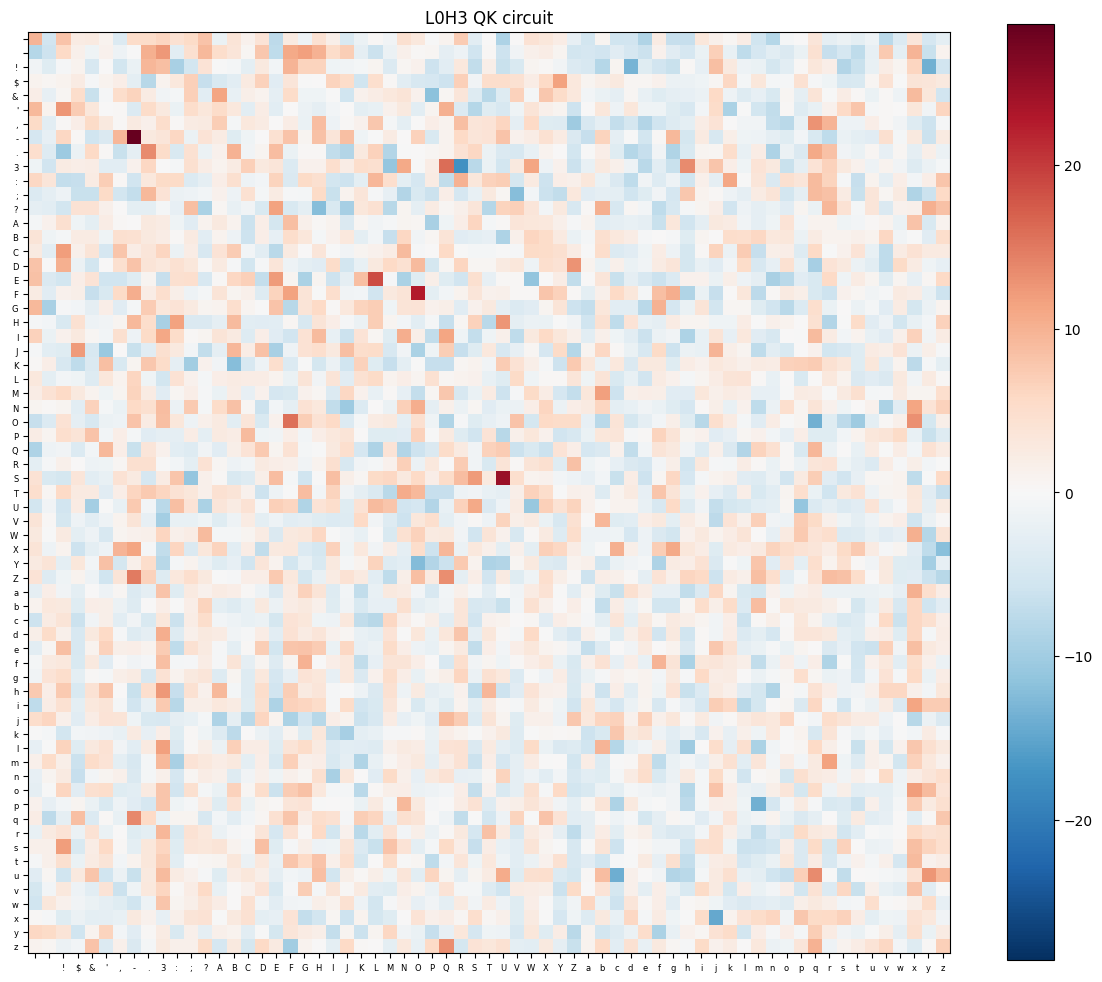

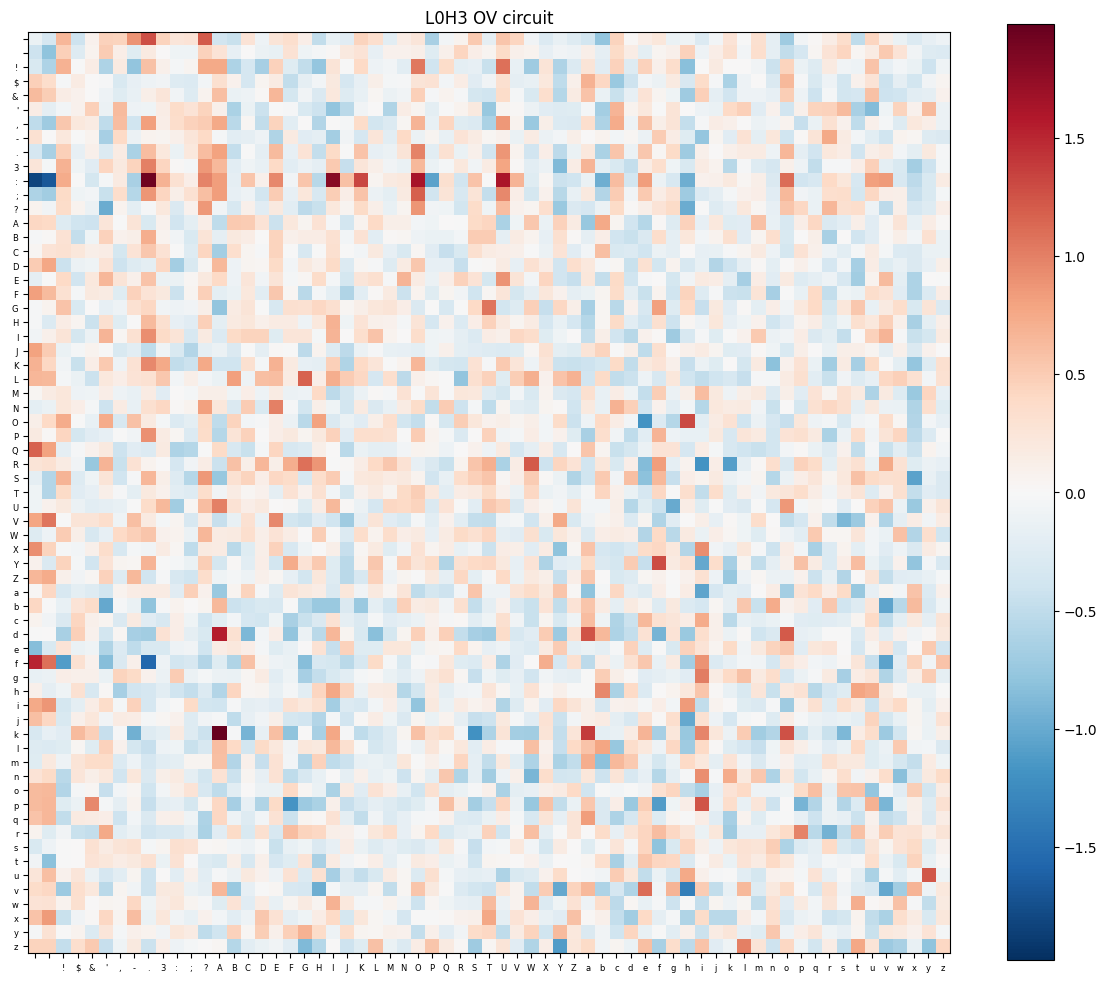

In [8]:
head = model.blocks[0].attention.heads[3]
W_E = model.token_embedding.weight # [65, 384]
W_U = model.lm_head.weight # [65, 384]

W_QK = head.W_Q.weight.T @ head.W_K.weight # (384, 384)
QK = W_E @ W_QK @ W_E.T

d_k = head.W_V.weight.shape[0]
h_idx = 3

W_V = head.W_V.weight
W_O = model.blocks[0].attention.proj.weight[:, h_idx*d_k:(h_idx+1)*d_k] # [384, 64]
OV = W_U @ W_O @ W_V @ W_E.T

import matplotlib.pyplot as plt

def plot_circuit(M, chars, title):
    M = M.detach().cpu().numpy()
    v = abs(M).max()

    fig, ax = plt.subplots(figsize=(12, 12))
    im = ax.imshow(M, cmap='RdBu_r', vmin=-v, vmax=v)

    ax.set_xticks(range(len(chars)))
    ax.set_yticks(range(len(chars)))
    ax.set_xticklabels(chars, fontsize=6)
    ax.set_yticklabels(chars, fontsize=6)

    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

plot_circuit(QK, sorted_chars, 'L0H3 QK circuit')
plot_circuit(OV, sorted_chars, 'L0H3 OV circuit')

In [9]:
from collections import Counter

counts = Counter(file_content)
freq = torch.tensor([counts[c] for c in sorted_chars], dtype=torch.float, device=QK.device)
freq = freq / freq.sum()

keep = freq > 0.001
mask = keep[:, None] & keep[None, :]
QK_filtered = QK*mask

def top_entries(M, chars, k=20):
    flat = M.detach().cpu().flatten()
    vals, idx = flat.topk(k)
    for v, i in zip(vals, idx):
        r, c = divmod(i.item(), len(chars))
        print(f'{repr(chars[r])} <- {repr(chars[c])}   {v.item():.3f}    ' f'(freq {freq[r]:.4f}, {freq[c]:.4f})')

print('Top QK Circuit entires(how much destination token attends to source token): ')
top_entries(QK_filtered, sorted_chars)
print('\n')
print('Top OV Circuit entries(effect on logit for out token if source token is attended): ')
top_entries(OV, sorted_chars)

Top QK Circuit entires(how much destination token attends to source token): 
'-' <- '-'   28.590    (freq 0.0017, 0.0017)
'S' <- 'U'   24.635    (freq 0.0041, 0.0030)
'F' <- 'O'   22.661    (freq 0.0016, 0.0049)
'E' <- 'L'   18.605    (freq 0.0054, 0.0035)
'O' <- 'F'   15.664    (freq 0.0049, 0.0016)
'.' <- '.'   13.576    (freq 0.0071, 0.0071)
'u' <- 'y'   12.657    (freq 0.0238, 0.0183)
"'" <- '!'   12.637    (freq 0.0055, 0.0019)
'H' <- 'U'   12.633    (freq 0.0028, 0.0030)
'S' <- 'S'   12.221    (freq 0.0041, 0.0041)
'E' <- 'E'   12.167    (freq 0.0054, 0.0054)
'C' <- '!'   12.045    (freq 0.0034, 0.0019)
's' <- '!'   11.887    (freq 0.0446, 0.0019)
' ' <- 'G'   11.663    (freq 0.1523, 0.0022)
'M' <- 'b'   11.640    (freq 0.0025, 0.0101)
'?' <- 'E'   11.489    (freq 0.0022, 0.0054)
'm' <- 'r'   11.451    (freq 0.0199, 0.0438)
'H' <- ':'   11.439    (freq 0.0028, 0.0092)
'F' <- 'F'   11.432    (freq 0.0016, 0.0016)
':' <- 'k'   11.051    (freq 0.0092, 0.0064)


Top OV Circuit entrie

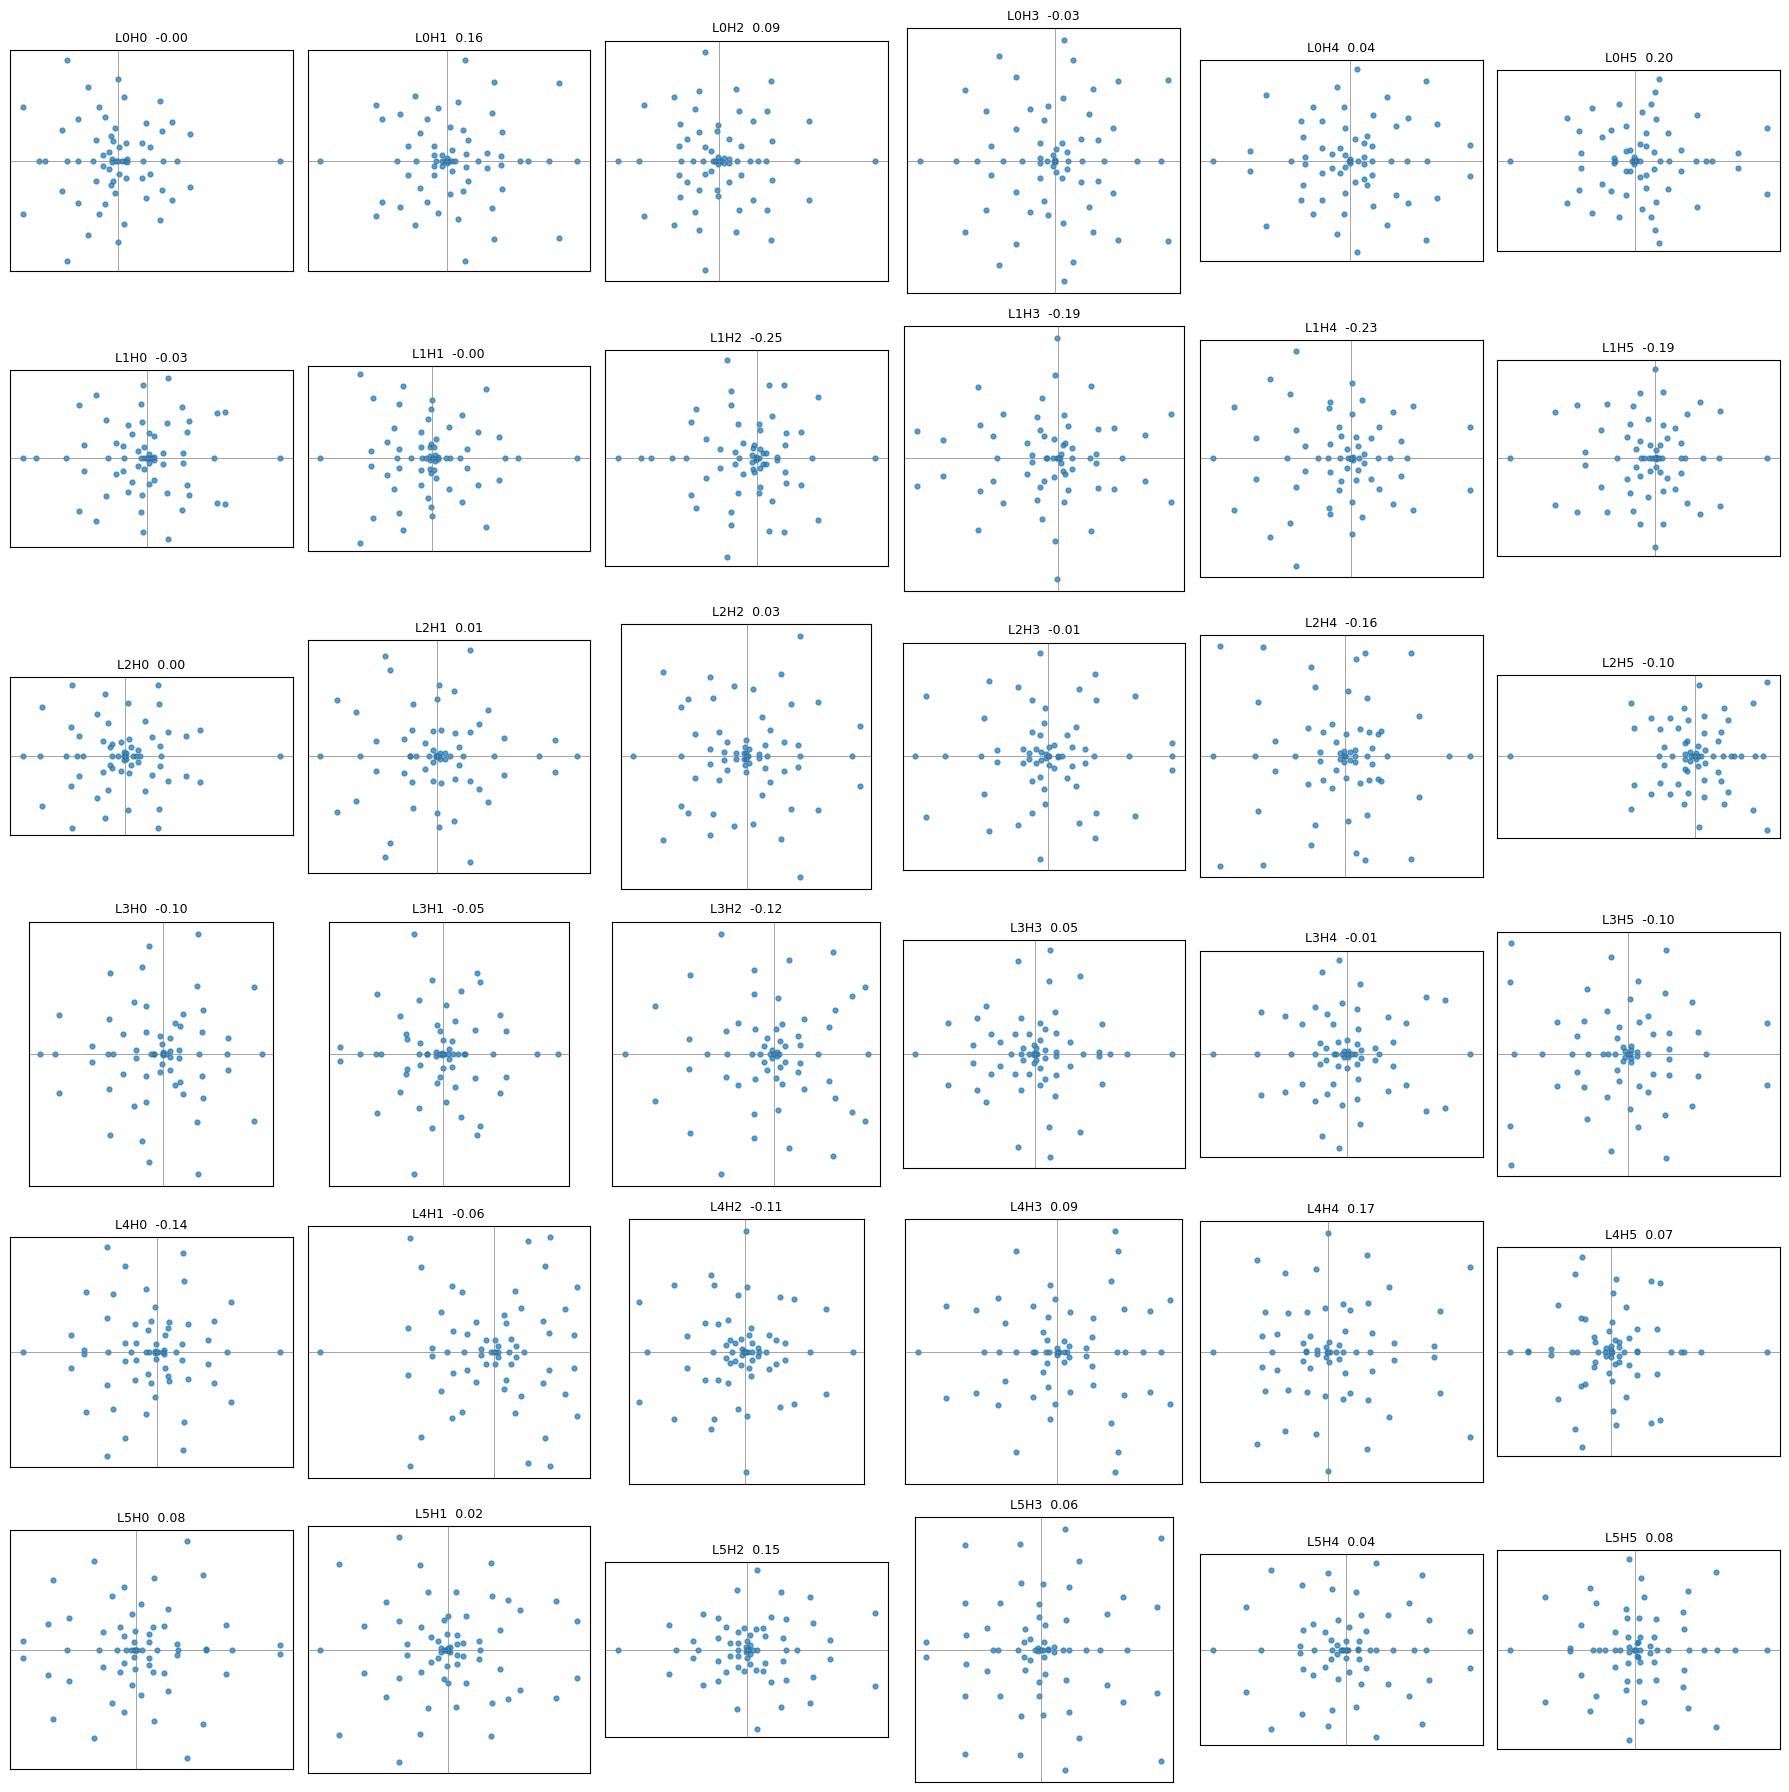

In [11]:
vals = np.linalg.eig(OV.detach().cpu().numpy())[0]

def ov_eigs(model, L, H, d_k=64):
    blk = model.blocks[L].attention
    s = slice(H*d_k, (H+1)*d_k)
    M = (model.lm_head.weight @ blk.proj.weight[:, s] @ blk.heads[H].W_V.weight @ model.token_embedding.weight.T)
    
    return np.linalg.eig(M.detach().cpu().numpy())[0]

n_layers, n_heads = 6, 6
fig, axes = plt.subplots(n_layers, n_heads, figsize=(3*n_heads, 3*n_layers))

for L in range(n_layers):
    for H in range(n_heads):
        v = ov_eigs(model, L, H)
        r = np.log1p(np.abs(v)) # log-scaled radius
        th = np.angle(v)
        x, y = r*np.cos(th), r*np.sin(th)

        ax = axes[L, H]
        ax.scatter(x, y, s=12, alpha=0.7)
        ax.axhline(0, lw=0.5, c='gray'); ax.axvline(0, lw=0.5, c='gray')
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        score = v.real.sum() / np.abs(v).sum()
        ax.set_title(f"L{L}H{H}  {score:.2f}", fontsize=9)

plt.tight_layout()

In [15]:
model.load_state_dict(torch.load('model.pt'))
model.eval()

xb, yb = get_batch('train', 8, 128)
with torch.no_grad():
    logits, loss = model(xb, yb)

print(loss.item())

1.1294140815734863


In [16]:
attn_cache = {}

def make_hook(name):
    def hook(module, inp, out):
        x = inp[0]
        Q, K = module.W_Q(x), module.W_K(x)
        s = Q @ K.transpose(-2,-1) / Q.shape[-1]**0.5

        T = s.shape[-1]
        s = s.masked_fill(module.tril[:T,:T] == 0, float('-inf'))
        attn_cache[name] = F.softmax(s, dim=-1).detach()

    return hook

for l, blk in enumerate(model.blocks):
    for h, head in enumerate(blk.attention.heads):
        head.register_forward_hook(make_hook(f'L{l}H{h}'))

seq = 'ROMEO: what news? '
text = seq * 3
idx = torch.tensor([encoder(text)], dtype=torch.long, device=device)

with torch.no_grad():
    model(idx)

print(len(attn_cache)) # 36
print(attn_cache['L0H0'].shape) # (1, T, T)


36
torch.Size([1, 54, 54])


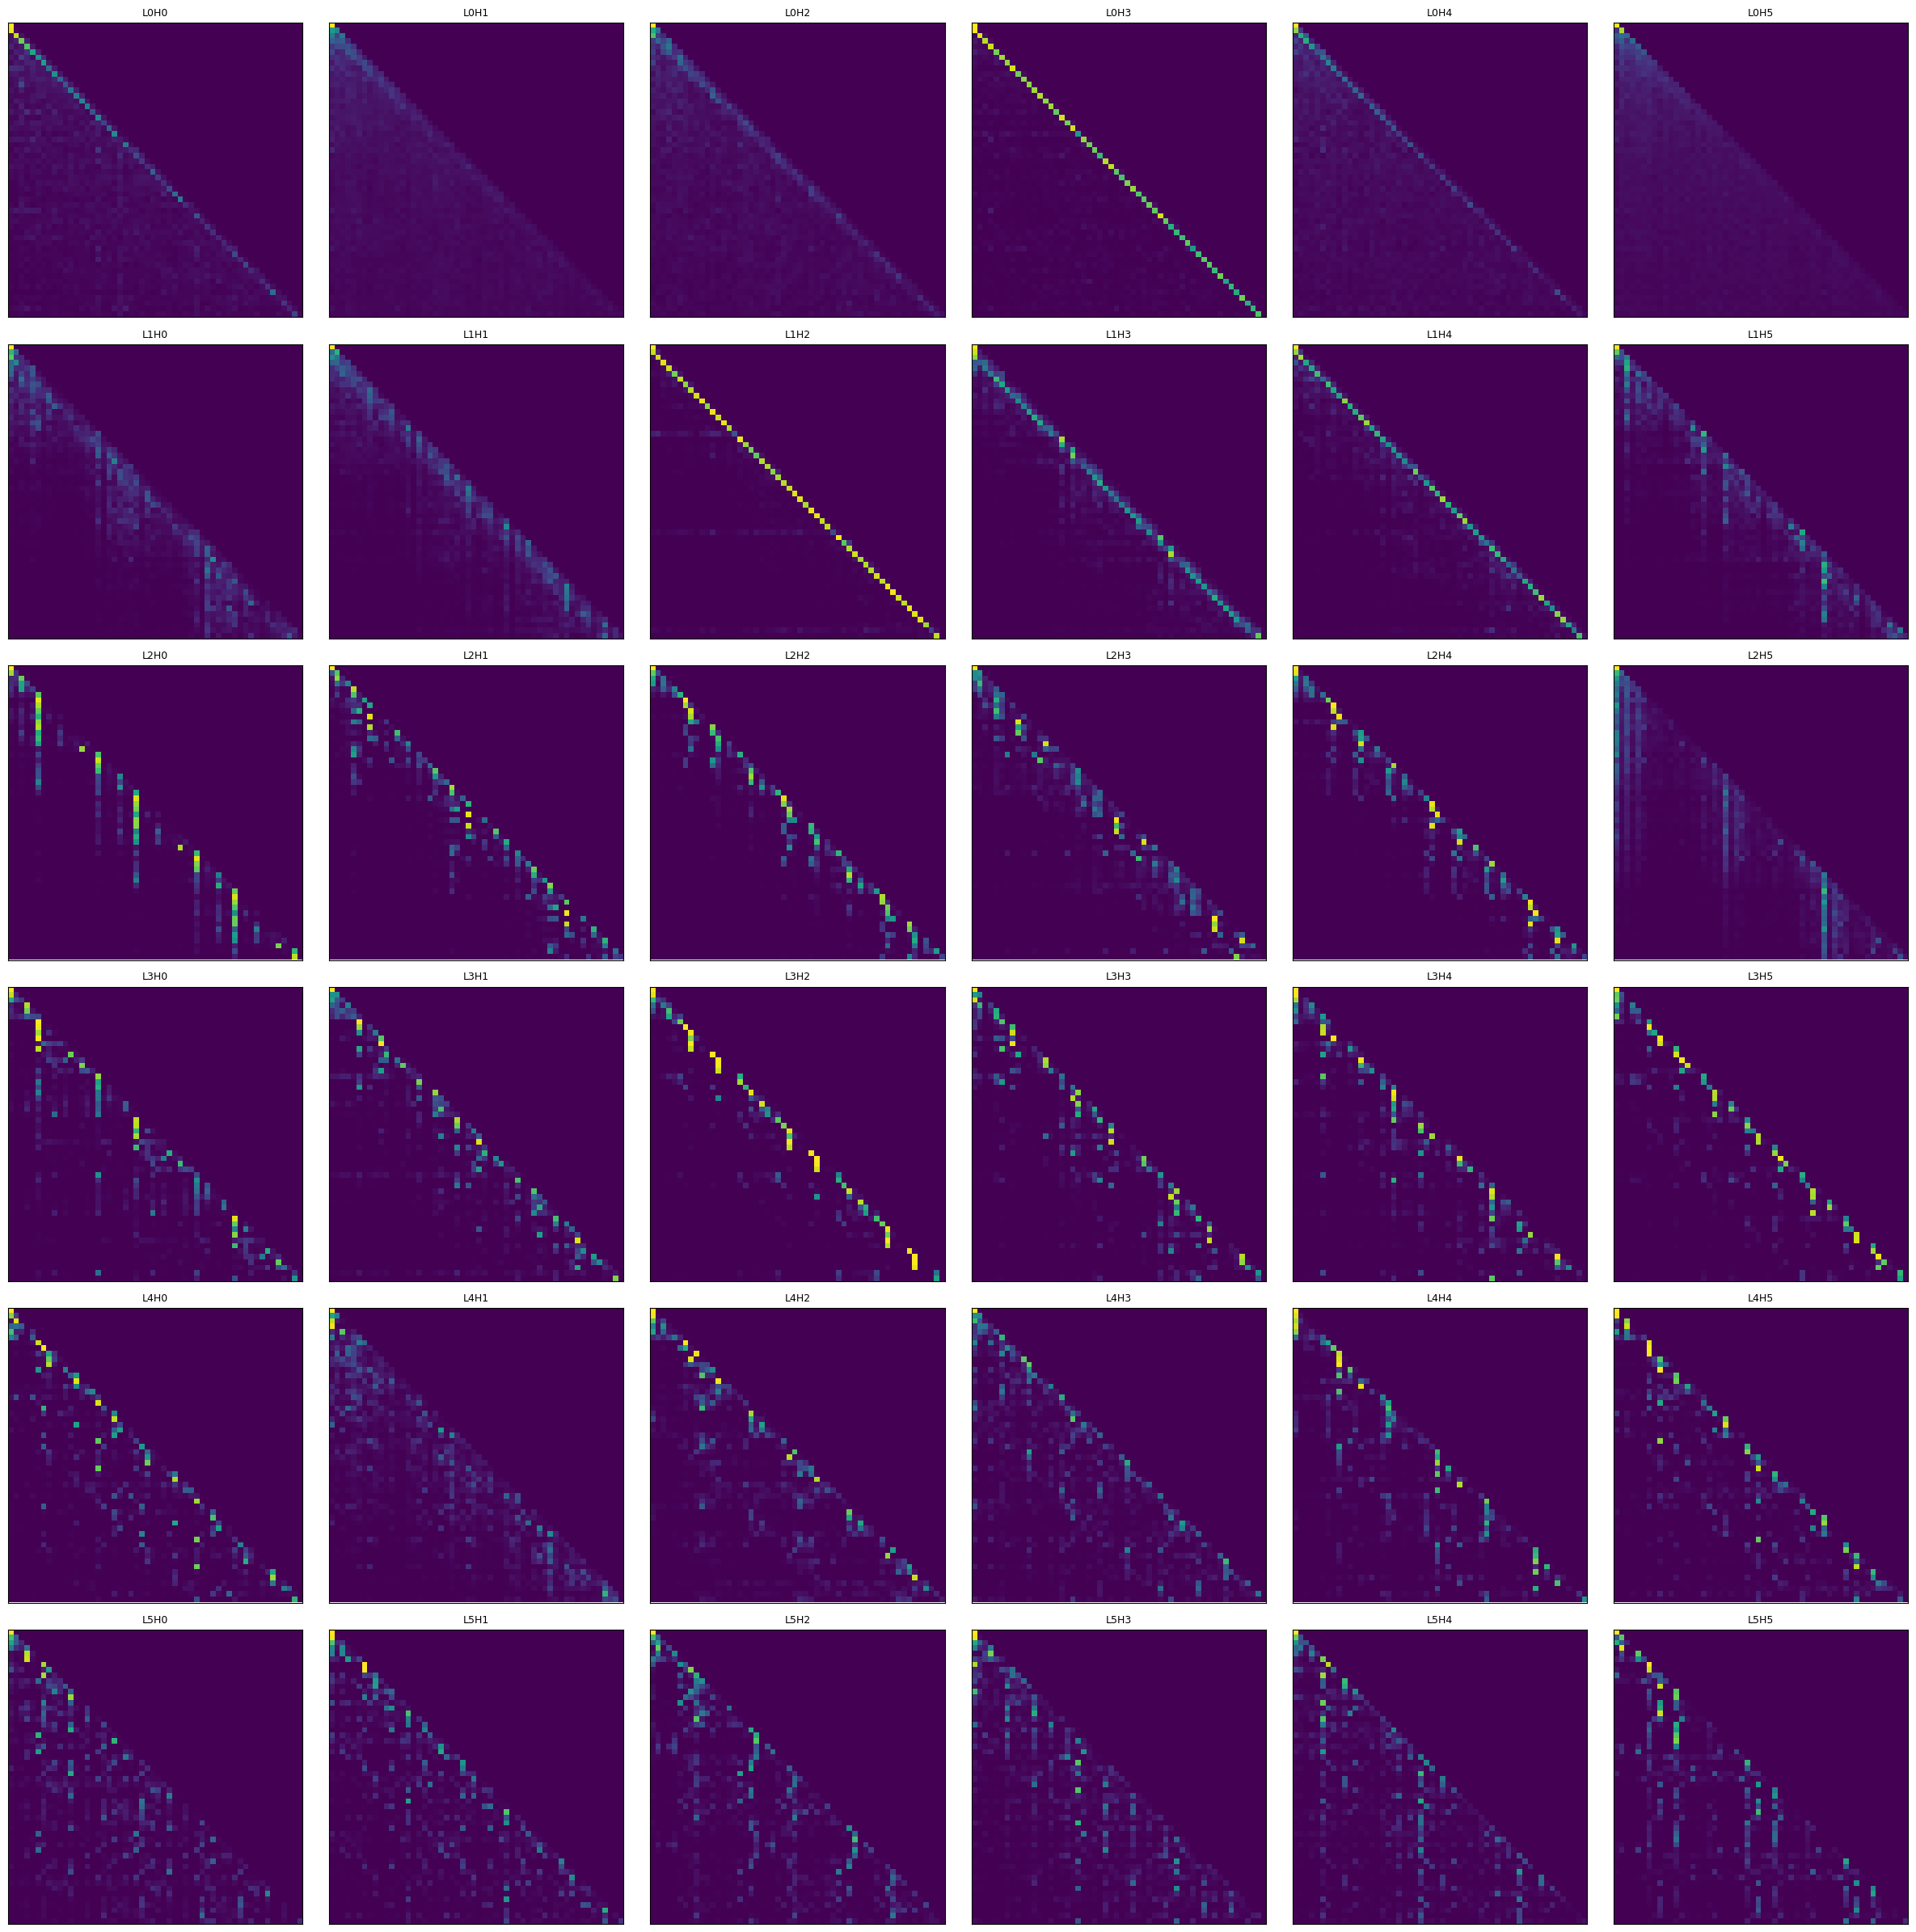

In [17]:
import matplotlib.pyplot as plt

chars = list(text)
T = len(text)

fig, axes = plt.subplots(6, 6, figsize=(24, 24))
for l in range(6):
    for h in range(6):
        ax = axes[l, h]
        w = attn_cache[f'L{l}H{h}'][0].cpu().numpy()
        
        ax.imshow(w, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'L{l}H{h}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show() # row(i) = query position | column(j) = key position
           # if, say, Cell (i, j) is bright, it means that token i is attending to token j(i is reading from j)
           # if a row has one super bright cell, the query is concentrating almost everything on that one key
           # in contrast, if a row is uniformally dim, the query is averaging broadly for each key -> diffuse attention, not weak 

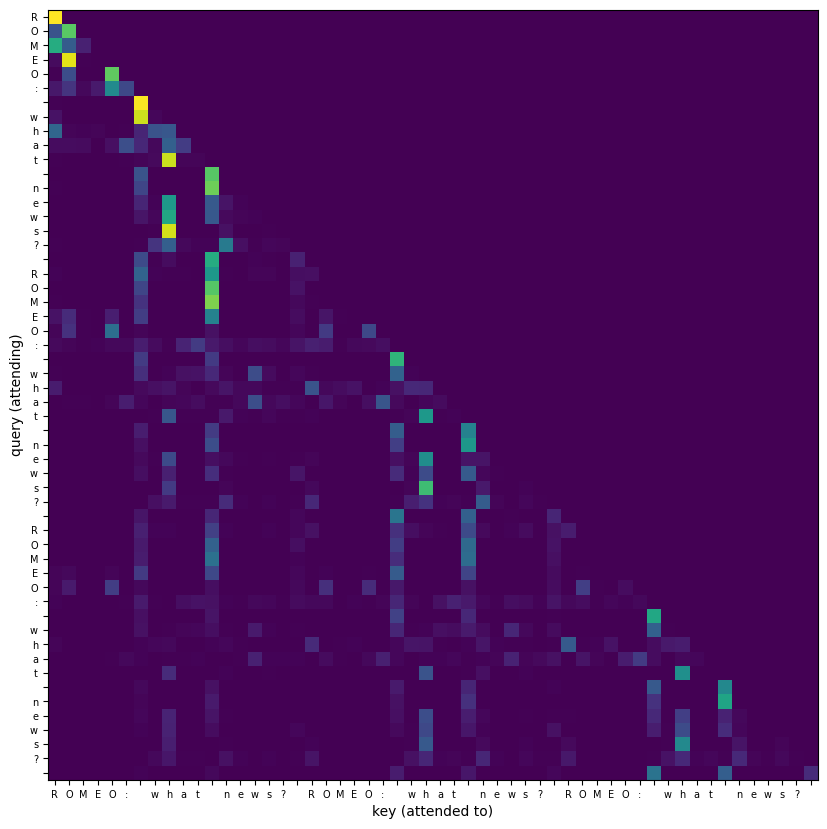

In [18]:
w = attn_cache['L5H5'][0].cpu().numpy()
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(w, cmap='viridis')
ax.set_xticks(range(T)); ax.set_xticklabels(chars, fontsize=7)
ax.set_yticks(range(T)); ax.set_yticklabels(chars, fontsize=7)
ax.set_xlabel('key (attended to)'); ax.set_ylabel('query (attending)')
plt.show()

In [24]:
import random

chars = sorted(set(file_content))
rand = ''.join(random.choices(chars, k=25))
text = rand * 3
idx = torch.tensor([encoder(text)], dtype=torch.long, device=device)

with torch.no_grad():
    model(idx)

for name, w in sorted(attn_cache.items()):
    a = w[0]
    rows = range(27, 54)
    
    m24 = sum(a[i, i-24].item() for i in rows) / len(list(rows))
    m18 = sum(a[i, i-18].item() for i in rows) / len(list(rows))
    m1  = sum(a[i, i-1].item()  for i in rows) / len(list(rows))
    
    if max(m24, m18) > 0.05:
        print(f'{name}: off24={m24:.3f} off18={m18:.3f} off1={m1:.3f}') # off24=0.017 and the off17's are all near the noise flow: no induction heads

L5H3: off24=0.053 off18=0.026 off1=0.054
